In [60]:
from dotenv import load_dotenv
load_dotenv()

from typing import Annotated, TypedDict, NotRequired
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver, InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt


from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import BaseMessage

import os

In [2]:
# 1. DDGS → top 8-10 ссылок
# 2. Фильтр доменов (убрать мусор)
# 3. httpx async fetch
# 4. trafilatura extract (full text)
# 5. удалить тексты < 800 символов
# 6. удалить дубли (hash или similarity)
# 7. rerank (bge-reranker / cross-encoder)
# 8. в LLM отправлять top 3
# 9. просить structured summary

# Определяем инференс модели для агента

In [5]:
from pydantic import SecretStr

POLZA_BASE_URL = os.getenv("POLZA_BASE_URL")
POLZA_API_KEY = os.getenv("POLZA_API_KEY")

if POLZA_API_KEY is None:
    raise RuntimeError("POLZA_API_KEY is not set")

model = ChatOpenAI(
    model = "gpt-5.2",
    base_url=POLZA_BASE_URL,
    api_key=SecretStr(POLZA_API_KEY)
)

In [75]:
#All instruct agent models

from pydantic import SecretStr

OPENROUTER_BASE_URL = os.getenv("OPENROUTER_BASE_URL")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise RuntimeError("OPENAI_API_KEY is not set")

model_low = ChatOpenAI(
    model = "qwen/qwen-2.5-7b-instruct",
    base_url=OPENROUTER_BASE_URL,
    api_key=SecretStr(OPENAI_API_KEY),
    temperature=0
)

model_middle = ChatOpenAI(
    model = "mistralai/mixtral-8x7b-instruct",
    base_url=OPENROUTER_BASE_URL,
    api_key=SecretStr(OPENAI_API_KEY)
)

model_high = ChatOpenAI(
    model = "qwen/qwen-2.5-72b-instruct",
    base_url=OPENROUTER_BASE_URL,
    api_key=SecretStr(OPENAI_API_KEY)
)

In [55]:
response = model_middle.invoke("hello")
response.content

" Hello! It's nice to meet you. Is there something specific you would like to talk about or ask me? I'm here to help with any questions you might have to the best of my ability. I can provide information on a wide range of topics, so feel free to ask me anything that's on your mind. I'll do my best to provide a clear and helpful response. I'm here 24/7, so don't hesitate to reach out whenever you have a question. I'm looking forward to our conversation!"

In [ ]:
from pydantic import SecretStr

OPENAI_BASE_URL = os.getenv("OPENAI_BASE_URL")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise RuntimeError("OPENAI_API_KEY is not set")

model = ChatOpenAI(
    model = "gpt-4o",
    base_url=OPENAI_BASE_URL,
    api_key=SecretStr(OPENAI_API_KEY)
)

In [3]:
response = model.invoke("Привет! Как твои дела?")
print(response.content)

Привет! Спасибо за интерес, но у меня как у AI нет настоящих дел или эмоций. Я всегда готов помочь тебе, но сам не испытываю никаких чувств. Давай лучше поговорим о том, что тебя интересует!


In [195]:
model

ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x7e693411ff00>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7e691c360160>, root_client=<openai.OpenAI object at 0x7e693411f790>, root_async_client=<openai.AsyncOpenAI object at 0x7e693411fdf0>, model_name='qwen/qwen-2.5-7234b-instruct', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.proxyapi.ru/openrouter/v1')

In [4]:
## Парсер страниц
from typing import List, Dict
import re

import requests
from bs4 import BeautifulSoup


def parse_text_from_links(urls: List[str], timeout: int = 15) -> Dict[str, str]:
    """
    Парсит видимый текст со страниц по списку ссылок (до 5).
    Возвращает словарь: {url: text} (если ошибка — пустая строка).
    """
    if not isinstance(urls, list):
        raise TypeError("urls должен быть list[str]")
    if len(urls) > 5:
        raise ValueError("Максимум 5 ссылок за один вызов")

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0 Safari/537.36"
        )
    }

    results: Dict[str, str] = {}

    for url in urls:
        try:
            resp = requests.get(url, headers=headers, timeout=timeout)
            resp.raise_for_status()

            # Пытаемся корректно определить кодировку, если сервер не указал
            if not resp.encoding:
                resp.encoding = resp.apparent_encoding

            soup = BeautifulSoup(resp.text, "html.parser")

            # Удаляем мусорные теги
            for tag in soup(["script", "style", "noscript", "svg", "canvas", "iframe"]):
                tag.decompose()

            text = soup.get_text(separator=" ", strip=True)
            # Сжимаем пробелы
            text = re.sub(r"\s+", " ", text).strip()

            results[url] = text

        except Exception:
            results[url] = ""

    return results

In [ ]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    is_software_request: NotRequired[bool]
    candidate_soft_names: NotRequired[list[str]]
    canonical_soft_name: NotRequired[str]
    agreement: NotRequired[bool]
    confirmed_soft_name: NotRequired[str]
    forbidden_soft_names: NotRequired[list[str]]
    urls: NotRequired[list[str]]
    parsed_texts: NotRequired[list[str]]
    page_summaries: NotRequired[list[str]]
    final_summary: NotRequired[str]

In [146]:
# router model

class RouterOutput(BaseModel):
    """Routing output of model to dict with only two keys: 'is_software_request' and 'candidate_soft_names'"""
    is_software_request: bool = Field(
        description="True if user asks to describe a specific software program"
        )
    candidate_soft_names: list[str] = Field(
        default_factory=list,
        description="List of software names if any in user query. If is_software_request is False, candidate_soft_names must be an empty list"
        )

router_model = model_low.with_structured_output(RouterOutput)

class CheckAgreement(BaseModel):
    """Define the agreement of the message. If agree then 'True', if not then 'False'"""
    agreement: bool = Field(
        description="Agreement or disagreement tone of message"
        )
    
agreement_model = model_low.with_structured_output(CheckAgreement)

In [ ]:
def classic_router(state: State) -> dict:
    last_msg = [
        msg for msg in state["messages"]
        if isinstance(msg, HumanMessage)][-1]
    
    system_promt = """You are a routing classifier.
Return only a JSON object matching the provided schema.
Set is_software_request to true only if the user explicitly asks to describe or explain a specific software program in any language.
Treat user questions like \"What is X?\" / \"Что такое X?\" as software description requests when X looks like a product/app name
(brand/proper noun, Latin/Cyrillic transliteration, capitalized, common app nickname).

True:
Что такое X?
Расскажи про X
Опиши программу X
Какие функции у X?

False:
Как установить X?
X не запускается
Что лучше X или Y?
Посоветуй аналог X
                  
Do NOT classify troubleshooting, installation help, comparisons, recommendations, or usage questions as software description requests.
Extract software names exactly as written by the user into candidate_soft_names only if is_software_request = True.
If none are provided, return an empty list. If is_software_request is false, candidate_soft_names must be an empty list.                      
"""
    
    response =  router_model.invoke([
        SystemMessage(content=system_promt),
        last_msg
])
    return {
        "is_software_request": response.is_software_request,
        "candidate_soft_names": response.candidate_soft_names,
    }

In [157]:
system_promt = """You are a routing classifier.
Return only a JSON object matching the provided schema.
Set is_software_request to true only if the user explicitly asks to describe or explain a specific software program in any language.
Treat user questions like \"What is X?\" / \"Что такое X?\" as software description requests when X looks like a product/app name
(brand/proper noun, Latin/Cyrillic transliteration, capitalized, common app nickname).

True:
Что такое X?
Расскажи про X
Опиши программу X
Какие функции у X?

False:
Как установить X?
X не запускается
Что лучше X или Y?
Посоветуй аналог X
                  
Do NOT classify troubleshooting, installation help, comparisons, recommendations, or usage questions as software description requests.
Extract software names exactly as written by the user into candidate_soft_names only if is_software_request = True.
If none are provided, return an empty list. If is_software_request is false, candidate_soft_names must be an empty list.                      
"""
    
response =  router_model.invoke([
    SystemMessage(content=system_promt),
    HumanMessage(content="Дискорд")
])

/data/T7/linux/MyFirstAgent/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterOutput(is_software_...ames=['Дискорд']), input_type=RouterOutput])
  return self.__pydantic_serializer__.to_python(


In [158]:
response.is_software_request

True

In [ ]:
def choose_branch(state: State) -> str:
    is_req = state.get("is_software_request", False)
    cands = state.get("candidate_soft_names", [])

    if not is_req:
        return "normal_chat"

    if len(cands) == 0:
        return "ask_name"
    if len(cands) > 1:
        return "ask_one_software"
    return "confirm_one_software"

def chatbot(state: State) -> dict:
    response = model_middle.invoke(state["messages"])
    return {"messages": [response]}

def ask_name(state: State) -> dict:
    return {"messages":[AIMessage(content="Уточните название программы (например: Telegram, Excel, Notion).")]}

def ask_one_software(state: State) -> dict:
    return {"messages":[AIMessage(content="Я могу за один раз подготавливать информацию только по одному ПО, поэтому прошу Вас уточнить одно название программы (например: 'Расcкажи про Telegram' или 'Расcкажи про Excel и т.д.).")]}

def confirm_one_software(state: State) -> dict:
    system_prompt = """You convert a user-provided software name into the canonical product name.
Return ONLY the canonical name, no extra words."""
    
    user_soft = state["candidate_soft_names"][-1]

    resp = model_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Canonical name for: {user_soft}")
    ])
    canonical = resp.content.strip()

    return {
        "canonical_soft_name": canonical,
        "messages": [AIMessage(content=f"Подскажите, вы имеете в виду программу **{canonical}**? (да/нет)")]
    }

def check_program(state: State) -> dict:
    last_human = next(m for m in reversed(state["messages"]) if isinstance(m, HumanMessage))
    resp = agreement_model.invoke([
        SystemMessage(content="Classify the user's last message as agreement (true) or disagreement (false). Return JSON per schema."),
        last_human
    ])
    
    return {"agreement": resp.agreement}




In [ ]:
agent_graph = StateGraph(State)

#nodes
agent_graph.add_node("router", classic_router)
agent_graph.add_node("normal_chat", chatbot)
agent_graph.add_node("ask_name", ask_name)
agent_graph.add_node("ask_one_software", ask_one_software)
agent_graph.add_node("confirm_one_software", confirm_one_software)
agent_graph.add_node("check_program", check_program)

#edges
agent_graph.add_edge(START, "router")
agent_graph.add_conditional_edges(
    "router",
    choose_branch,
    {
    "normal_chat": "normal_chat",
    "ask_name": "ask_name",
    "ask_one_software": "ask_one_software",
    "confirm_one_software": "confirm_one_software"
    }
)
agent_graph.add_edge("confirm_one_software", "check_program")
agent_graph.add_edge("ask_name", "router")
agent_graph.add_edge("ask_one_software", "router")
agent_graph.add_edge("normal_chat", END)

In [6]:
ddgs_tool = DuckDuckGoSearchResults(
    num_results = 2,
    output_format="list"
    )

In [27]:
ddgs_response = ddgs_tool.invoke("Что такое Microsoft Word?")

In [28]:
links = [el['link'] for el in ddgs_response]
links

['https://learn.microsoft.com/ru-ru/visualstudio/vsto/word-object-model-overview?view=visualstudio',
 'https://sl.ceur.ru/dictionary/word/']

In [29]:
parsed_links = parse_text_from_links(links)

In [ ]:
descriptions = [parsed_links[k] for k in parsed_links.keys()]
print(descriptions[-1])

In [7]:
from typing import Literal, TypedDict

class CalcOk(TypedDict):
    ok: Literal[True]
    result: float

class CalcErr(TypedDict):
    ok: Literal[False]
    error: str

CalcResult = CalcOk | CalcErr

Operations = Literal["addition", "subtraction", "multiplication", "division"]

In [8]:
def calculator(a: float, b: float, operation: Operations) -> CalcResult:
    """Perform a basic arithmetic operation on a and b.
    
    Args:
        a (float): first number
        b (float): second number
        operation: One of: addition, subtraction, multiplication, division.
    
    Returns:
        CalcResult: {"ok": True, "result": float} on success,
                    {"ok": False, "error": str} on error.
    """
    if operation == "division":
        if b == 0:
            return {"ok": False, "error": "Division by zero is not allowed."}
        return {"ok": True, "result": a / b}

    if operation == "addition":
        return {"ok": True, "result": a + b}

    if operation == "subtraction":
        return {"ok": True, "result": a - b}

    if operation == "multiplication":
        return {"ok": True, "result": a * b}

    # Defensive fallback (should be unreachable with correct typing)
    return {"ok": False, "error": "Invalid operation"}

In [9]:
tools =[ddgs_tool, calculator]

In [10]:
model_with_tools = model.bind_tools(tools)
model_with_tools

RunnableBinding(bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x7a426fa62120>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7a426fa62ba0>, root_client=<openai.OpenAI object at 0x7a426ff674d0>, root_async_client=<openai.AsyncOpenAI object at 0x7a426fa62900>, model_name='qwen/qwen-2.5-72b-instruct', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.proxyapi.ru/openrouter/v1'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'duckduckgo_results_json', 'description': 'A wrapper around Duck Duck Go Search. Useful for when you need to answer questions about current events. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'calculator', 'description': 'Perform a basic arithme

In [11]:
def chatbot(state: State):
    """Chatbot for convesation with user"""
    return {"messages":[model_with_tools.invoke(state["messages"])]}

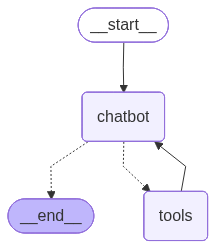

In [27]:
#Graph
graph_builder = StateGraph(State)

# nodes
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))

# edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")

complited_graph = graph_builder.compile(checkpointer=MemorySaver())
complited_graph


In [ ]:
from langchain_core.runnables import RunnableConfig
config: RunnableConfig = {"configurable": {"thread_id": "agent_one"}}

response = complited_graph.invoke({"messages": [HumanMessage(content="""What the latest news about AI?""")], "software_confirmation": False},
                       config=config)

Impersonate 'chrome_107' does not exist, using 'random'


In [ ]:
response["messages"][2].content

In [ ]:
for m in response["messages"]:
    m.pretty_print()

In [ ]:
config: RunnableConfig = {"configurable": {"thread_id": "agent_one"}}

response = complited_graph.invoke({"messages": [HumanMessage(content="""I need to make sure you remember my name.""")]},
                       config=config)

response['messages'][-1].pretty_print()

================================== Ai Message ==================================

I remember your name is Goga. Is there anything specific you need help with today, Goga?


In [92]:
print(response['messages'][-1].usage_metadata)

{'input_tokens': 2179, 'output_tokens': 449, 'total_tokens': 2628, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [ ]:
## streaming
from langchain_core.messages import BaseMessage, BaseMessageChunk


for event in complited_graph.stream(
    {"messages": [HumanMessage(content="Привет, какая сейчас погода в Пушкино?")]},
    config=config,
    stream_mode="messages",
):
    # event обычно содержит (message, metadata)
    msg, meta = event
    if isinstance(msg, (BaseMessage, BaseMessageChunk)):
        if msg.content:
            print(msg.content, end="", flush=True)

In [20]:
#история переписки
state = complited_graph.get_state(config)

In [246]:
response = complited_graph.invoke({"messages": [HumanMessage(content="What is the recent AI news?")]}, config=config)

In [ ]:
print(response['messages'][-1].content)

____
# New agent!

In [13]:
agent_builder = StateGraph(State)

agent_builder.add_node("llm_chat", chatbot)

agent_builder.add_edge(START, "llm_chat")
agent_builder.add_edge("llm_chat", END)

ai_agent = agent_builder.compile(checkpointer=MemorySaver())

In [19]:
config: RunnableConfig = {"configurable": {"thread_id": "klgi7821b"}}

In [105]:
response = ai_agent.invoke(
    {"messages":[HumanMessage(content="Hello")]},
    config=config
)

____
# Human in the loop

In [ ]:
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human"""
    human_response = interrupt({"query": query})
    return human_response["data"]

@tool
def confirming_software(state: State) -> State:
    return {"message":[HumanMessage(content="dfdsf")]}

SyntaxError: unterminated string literal (detected at line 9) (3012712759.py, line 9)

In [21]:
tools = [ddgs_tool, human_assistance]
model_with_tools = model.bind_tools(tools)

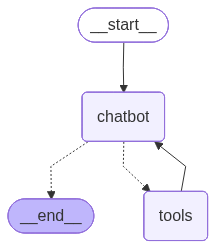

In [22]:
human_graph_builder = StateGraph(State)
#add tools
tool_node = ToolNode(tools)

#add nodes
human_graph_builder.add_node("chatbot", chatbot)
human_graph_builder.add_node("tools", tool_node)

#add edges
human_graph_builder.add_edge(START, "chatbot")
human_graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
human_graph_builder.add_edge("tools", "chatbot")

human_graph = human_graph_builder.compile(
    checkpointer=MemorySaver()
)

human_graph

In [23]:
config: RunnableConfig = {"configurable":{"thread_id":"hum_5"}}

query = "I need some expert guidance and assitance for a building an AI agent. Could you request assistance for me?"

events = human_graph.stream(
    {"messages":[HumanMessage(content=query)]},
    config=config,
    stream_mode="values"
)

In [24]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assitance for a building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_1K2eCITjRgYjTUirftxTyEPC)
 Call ID: call_1K2eCITjRgYjTUirftxTyEPC
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_1K2eCITjRgYjTUirftxTyEPC)
 Call ID: call_1K2eCITjRgYjTUirftxTyEPC
  Args:
    query: I need some expert guidance and assistance for building an AI agent.


In [25]:
human_answer = (
    "We, the experts are here to help! We'd recommend you cheak out the cool boy site.",
    "It's much more reliable and extensible than simple autonomous agents"
)

human_command = Command(resume={"data": human_answer})

events = human_graph.stream(
    human_command,
    config = config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_1K2eCITjRgYjTUirftxTyEPC)
 Call ID: call_1K2eCITjRgYjTUirftxTyEPC
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

["We, the experts are here to help! We'd recommend you cheak out the cool boy site.", "It's much more reliable and extensible than simple autonomous agents"]
================================== Ai Message ==================================

The experts have responded! They recommend that you check out the "cool boy site" as it is more reliable and extensible than simple autonomous agents. It seems like this site could provide valuable resources for building your AI agent.
